In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sys
sys.path.append('/home/fverdian/class/soundspeed-scripts/numerical-integrals')
from num_kernels import NumKernels
from scipy.integrate import odeint

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern"],
})

In [2]:
fx=0.1
t_ini = -7
fullt=np.linspace(t_ini,3, 300)
teval=0
kref=1
supprshift=8
p=2
nk = NumKernels(fx=fx, kref=kref, fullt=fullt, rtol=0.01, p=p, supprshift=supprshift)
def g_ank(k):
    return nk.g_an(-(2+p)*np.log(k/kref))
def h_ank(k):
    return nk.h_an(-(2+p)*np.log(k/kref))

def g_numk(k):
    return nk.g_num(-(2+p)*np.log(k/kref))
def h_numk(k):
    return nk.h_num(-(2+p)*np.log(k/kref))

In [3]:
def solve_F2_wqp( triplet, return_timedep=False):
    k1 , k2, cT = triplet
    kref = nk.kref
    fx=nk.fx
    p=nk.p
    Fc2_0=(5./7.+6/245*fx)*nk.alphas(k1,k2,cT)+(2./7.-6/245*fx)*nk.beta(k1,k2,cT)
    Gc2_0=(3./7-51/245*fx)*nk.alphas(k1,k2,cT)+(4./7-96/245*fx)*nk.beta(k1,k2,cT)

    def F2_system(w, t):
        Fc2,Gc2,Fx2,Gx2 = w
        g_c_k1=nk.g_c_int(t-(2+p)*np.log(k1/kref)); g_c_k2=nk.g_c_int(t-(2+p)*np.log(k2/kref))
        g_k1=nk.g_num(t-(2+p)*np.log(k1/kref)); g_k2=nk.g_num(t-(2+p)*np.log(k2/kref))
        h_k1=nk.h_num(t-(2+p)*np.log(k1/kref)); h_k2=nk.h_num(t-(2+p)*np.log(k2/kref))
                                                        
        SF2=0.5*g_c_k1*nk.alpha(k1,k2,cT)+0.5*g_c_k2*nk.alpha(k2,k1,cT)
        dFc2dt = -(g_c_k1+g_c_k2)*Fc2 + Gc2 + SF2
        dGc2dt = -(0.5+g_c_k1+g_c_k2)*Gc2 + 1.5 *((1-fx)*Fc2+fx*Fx2) +g_c_k1*g_c_k2*nk.beta(k1,k2,cT)

        SF2=0.5*g_k2*h_k1*nk.alpha(k1,k2,cT)+0.5*g_k1*h_k2*nk.alpha(k2,k1,cT)
        dFx2dt = -(g_c_k1+g_c_k2)*Fx2 + Gx2 + SF2
        dGx2dt = -(0.5+g_c_k1+g_c_k2)*Gx2 + 1.5 *((1-fx)*Fc2+(fx-(k1**2+k2**2+2*k1*k2*cT)**(2)/(kref**(4))*np.exp(-t))*Fx2) + h_k1*h_k2*nk.beta(k1,k2,cT)  -(k1**2+k2**2+2*k1*k2*cT)**(0.5*p+1)/(kref**(2+p))*np.exp(-t-nk.supprshift)*dFx2dt

        dGx2dt += 1.5*(k1**2+k2**2+2*k1*k2*cT)**(2)/(kref**(4))*np.exp(-t) * 1/4*(1+(k1**2 +k2**2)/(k1**2+k2**2+2*k1*k2*cT))*g_k1*g_k2

        return [dFc2dt, dGc2dt,dFx2dt, dGx2dt]

    sol = odeint(F2_system, [Fc2_0,Gc2_0,0.,0.], nk.fullt, rtol=nk.rtol)
    if return_timedep:
        return sol
    return sol[nk.idx_eta]

In [6]:
mup=0.

kphigh=8.
qlist=np.logspace(-3,np.log10(50),30)

Flist_high=[];Glist_high=[]

for qp in qlist:
    print(f'q={qp:.1e}', end='\r', flush=True)
    kMq = np.sqrt(kphigh**2 + qp**2 - 2*kphigh*qp*mup)
    cT12 = (kphigh*mup-qp)/kMq
    F2c_wqp,G2c_wqp,F2x_wqp,G2x_wqp=solve_F2_wqp([qp,kMq,cT12], return_timedep=False)
    F2c_pf,G2c_pf,F2x_pf,G2x_pf=nk.solve_F2([qp,kMq,cT12], return_timedep=False)

    Flist_high.append([F2x_wqp, g_numk(kphigh)*nk.F2_0(kphigh,qp,mup), F2x_pf])
    Glist_high.append([G2x_wqp, h_ank(kphigh)*nk.G2_0(kphigh,qp,mup), G2x_pf])

Flist_high=np.array(Flist_high).T;Glist_high=np.array(Glist_high).T

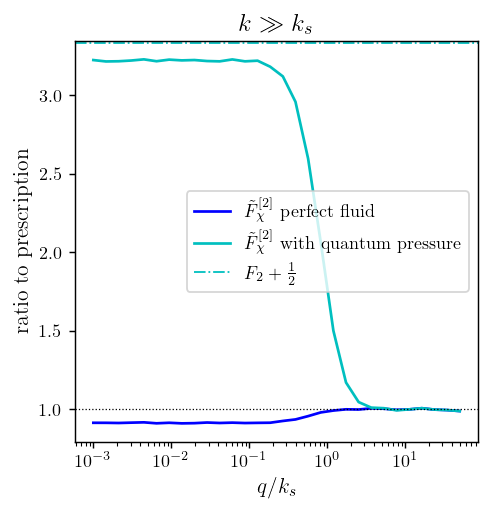

In [5]:
plt.figure(figsize=(4,4), dpi=130)
plt.plot(qlist,Flist_high[2]/Flist_high[1], 'b', label=r'$\tilde F_\chi^{[2]}$ perfect fluid')
plt.plot(qlist,Flist_high[0]/Flist_high[1], 'c', label=r'$\tilde F_\chi^{[2]}$ with quantum pressure')

# plt.plot(qlist,Glist_high[2]/Glist_high[1], 'm', label=r'$\tilde G_\chi^{[2]}$ perfect fluid')
# plt.plot(qlist,Glist_high[0]/Glist_high[1], 'purple', label=r'$\tilde G_\chi^{[2]}$ with quantum pressure')

plt.axhline(1, color='k', linestyle=':', linewidth=0.7)
# plt.plot(qlist, 'b', label=r'$\tilde F_\chi^{[2]}$ num')
plt.axhline(10/3, color='c', linestyle='-.', linewidth=1., label=r'$F_2+\frac{1}{2}$')

plt.xscale('log')
plt.legend()
plt.ylabel(r'ratio to prescription', fontsize=12)
plt.xlabel(r'$q/k_s$', fontsize=12)
plt.title(r'$k\gg k_s$', fontsize=14)

plt.show()

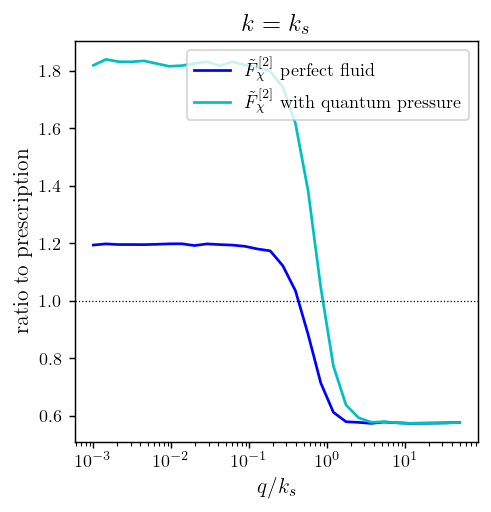

In [53]:
mup=0.

kphigh=1.
qlist=np.logspace(-3,np.log10(50),30)

Flist_high=[];Glist_high=[]

for qp in qlist:
    print(f'q={qp:.1e}', end='\r', flush=True)
    kMq = np.sqrt(kphigh**2 + qp**2 - 2*kphigh*qp*mup)
    cT12 = (kphigh*mup-qp)/kMq
    F2c_wqp,G2c_wqp,F2x_wqp,G2x_wqp=solve_F2_wqp([qp,kMq,cT12], return_timedep=False)
    F2c_pf,G2c_pf,F2x_pf,G2x_pf=nk.solve_F2([qp,kMq,cT12], return_timedep=False)

    Flist_high.append([F2x_wqp, g_numk(kphigh)*nk.F2_0(kphigh,qp,mup), F2x_pf])
    Glist_high.append([G2x_wqp, h_ank(kphigh)*nk.G2_0(kphigh,qp,mup), G2x_pf])

Flist_high=np.array(Flist_high).T;Glist_high=np.array(Glist_high).T
plt.figure(figsize=(4,4), dpi=130)
plt.plot(qlist,Flist_high[2]/Flist_high[1], 'b', label=r'$\tilde F_\chi^{[2]}$ perfect fluid')
plt.plot(qlist,Flist_high[0]/Flist_high[1], 'c', label=r'$\tilde F_\chi^{[2]}$ with quantum pressure')

# plt.plot(qlist,Glist_high[2]/Glist_high[1], 'm', label=r'$\tilde G_\chi^{[2]}$ perfect fluid')
# plt.plot(qlist,Glist_high[0]/Glist_high[1], 'purple', label=r'$\tilde G_\chi^{[2]}$ with quantum pressure')

plt.axhline(1, color='k', linestyle=':', linewidth=0.7)
# plt.plot(qlist, 'b', label=r'$\tilde F_\chi^{[2]}$ num')

plt.xscale('log')
plt.legend()
plt.ylabel(r'ratio to prescription', fontsize=12)
plt.xlabel(r'$q/k_s$', fontsize=12)
plt.title(r'$k= k_s$', fontsize=14)

plt.show()

----
Third order

In [7]:

def solve_F3_wqp(triplet, return_timedep=False):
    k , q, mu = triplet
    kref = nk.kref
    fx=nk.fx     
    p=nk.p

    ker2_k_mq_full=solve_F2_wqp([k,q,-mu], return_timedep=True)
    ker2_k_q_full=solve_F2_wqp([k,q,mu], return_timedep=True)

    # Relevant expressions for alpha and beta couplings
    x=k/q;x2=x*x
    a_q_kMq=mu*x;a_kMq_q=x*(x-mu)/(x2-2*x*mu+1)
    b_q_kMq=x2*(mu*x-1)/2./(x2-2.*mu*x+1.)
    a_q_kPq=-mu*x;a_kPq_q=x*(x+mu)/(x2+2*x*mu+1)
    b_q_kPq=-x2*(mu*x+1)/2./(x2+2.*mu*x+1.)
    
    def F3_system(w, t):

        Fc3,Gc3,Fx3,Gx3 = w
        g_c_k=nk.g_c_int(t-(2+p)*np.log(k/kref));g_c_q=nk.g_c_int(t-(2+p)*np.log(q/kref))
        g_q=nk.g_num(t-(2+p)*np.log(q/kref)); h_q=nk.h_num(t-(2+p)*np.log(q/kref))
        fact=(g_c_k+2*g_c_q)

        idx_t_F3=np.abs(nk.fullt - t).argmin()
        ker2_k_mq=ker2_k_mq_full[idx_t_F3]
        ker2_k_q=ker2_k_q_full[idx_t_F3]
        # ker2_k_mq=np.array([ker2_k_mq_int(t) for ker2_k_mq_int in ker2_k_mq_int])
        # ker2_k_q=np.array([ker2_k_q_int(t) for ker2_k_q_int in ker2_k_q_int])

        #F3_c and G3_c
        SF3=g_c_q*a_q_kMq*ker2_k_mq[0]+a_kMq_q*ker2_k_mq[1]
        SG3=g_c_q*b_q_kMq*2*ker2_k_mq[1]
        SF3+=g_c_q*a_q_kPq*ker2_k_q[0]+a_kPq_q*ker2_k_q[1]
        SG3+=g_c_q*b_q_kPq*2*ker2_k_q[1]

        dFc3dt = -fact*Fc3 + Gc3 + SF3/3
        dGc3dt = -(0.5+fact)*Gc3 + 1.5*((1-fx)*Fc3+fx*Fx3) + SG3/3

        #F3_x and G3_x
        SF3x=h_q*a_q_kMq*ker2_k_mq[2]+g_q*a_kMq_q*ker2_k_mq[3]
        SG3x=h_q*b_q_kMq*2*ker2_k_mq[3]
        SF3x+=h_q*a_q_kPq*ker2_k_q[2]+g_q*a_kPq_q*ker2_k_q[3]
        SG3x+=h_q*b_q_kPq*2*ker2_k_q[3]

        dFx3dt = -fact*Fx3 + Gx3 + SF3x/3
        dGx3dt = -(0.5+fact)*Gx3 + 1.5*((1-fx)*Fc3+(fx-(k**(2+p))/(kref**(2+p))*np.exp(-t))*Fx3) + SG3x/3 -(k**2)/(kref**2)*np.exp(-t-nk.supprshift)*dFx3dt

        dGx3dt += -1.5*(k/kref)**(4)*np.exp(-t) * 1/8*(8/3*(1/x2+1))*g_q*g_q*nk.g_num(t-(2+p)*np.log(k/kref))

        return [dFc3dt, dGc3dt,dFx3dt, dGx3dt]
    tsol = nk.fullt[:nk.idx_eta+2]
    sol = odeint(F3_system, [nk.F3_0(k,q,mu),nk.G3_0(k,q,mu),0,0], tsol, rtol=nk.rtol)
    if return_timedep:
        return tsol, sol
    # print(sol[nk.idx_eta], triplet[1:])
    return sol[nk.idx_eta]

In [13]:
mup=0. #MUST EVALUATE IT AT mu=0, otherwise the eds has a divergence
kplow=7.
qlist=np.logspace(-1,np.log10(1),25)
F3list_low=[]
for qp in qlist:
    print(f'q={qp:.1e}', end='\r', flush=True)
    F3c_wqp,_,F3x_wqp,_=solve_F3_wqp([kplow,qp,mup], return_timedep=False)
    F3c_pf,_,F3x_pf,_=nk.solve_F3([kplow,qp,mup], return_timedep=False)
    F3list_low.append([F3x_wqp/g_ank(kplow),nk.F3_0(kplow,qp,mup),F3x_pf/g_ank(kplow)])
F3list_low=np.array(F3list_low).T;

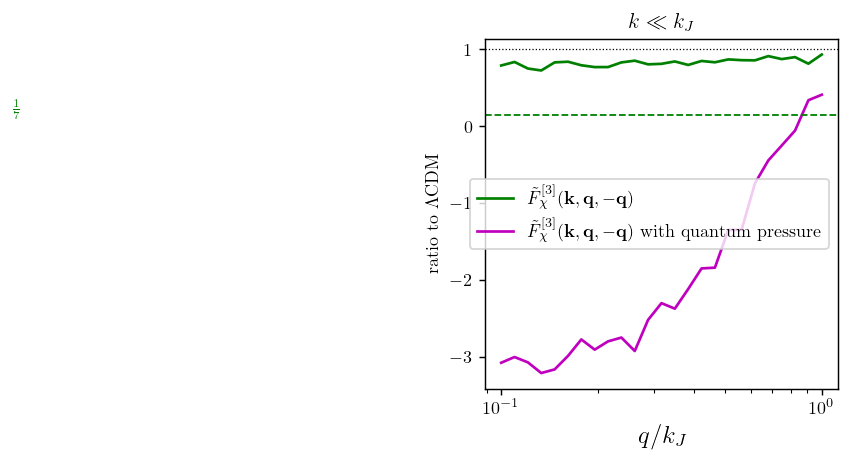

In [14]:
plt.figure(figsize=(3.5, 3.5), dpi=130)

# Second plot
plt.plot(qlist,F3list_low[2]/F3list_low[1], 'g', label=r'$\tilde F_\chi^{[3]}(\mathbf{k},\mathbf{q},-\mathbf{q})$')
plt.plot(qlist,F3list_low[0]/F3list_low[1], 'm', label=r'$\tilde F_\chi^{[3]}(\mathbf{k},\mathbf{q},-\mathbf{q})$ with quantum pressure')
plt.axhline(1/7, color='g', linestyle='--', linewidth=1)
plt.text(3.e-3, 0.17, r'$\frac{1}{7}$', color='g', fontsize=9)


plt.axhline(1, color='k', linestyle=':', linewidth=0.7)
plt.legend()
# plt.ylim([0.,None])
plt.title(r'$k\ll k_J$')
plt.ylabel(r'ratio to $\Lambda$CDM', fontsize=10)
plt.xscale('log')
plt.xlabel(r'$q/k_J$', fontsize=14)
# plt.savefig('/home/fverdian/class/soundspeed-scripts/figure/F23chi.pdf', bbox_inches='tight')
plt.show()

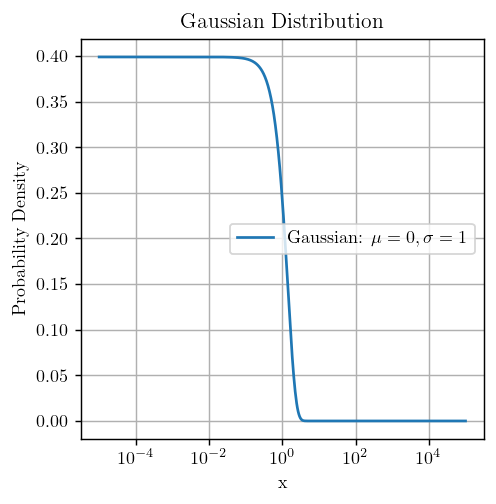

In [4]:
x = np.logspace(-5, 5, 500)
mu, sigma = 0, 1  # Mean and standard deviation
gaussian = (1 / (sigma * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((x - mu) / sigma) ** 2)

plt.figure(figsize=(4, 4), dpi=130)
plt.plot(x, gaussian, label=r'Gaussian: $\mu=0, \sigma=1$')
plt.title('Gaussian Distribution')
plt.xlabel('x')
plt.xscale('log')
plt.ylabel('Probability Density')
plt.legend()
plt.grid()
plt.show()